<a href="https://colab.research.google.com/github/tmq24/Digital-Image-Analysis-and-Processing/blob/main/noise_and_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up lib

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import os
import gdown

#Dowload IMG

In [ ]:
gdown.download('https://drive.google.com/uc?export=download&id=1wYsLRWkvj-KgXes3LWHwQCx8MZjC4Fjs', 'KarlMax.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1as_AvVeOmRTWm3RNWL6kUmW9PtR51oEo', 'Fruit.jpg', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1wYsLRWkvj-KgXes3LWHwQCx8MZjC4Fjs
To: /content/KarlMax.jpg
100%|██████████| 163k/163k [00:00<00:00, 40.0MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1as_AvVeOmRTWm3RNWL6kUmW9PtR51oEo
To: /content/Fruit.jpg
100%|██████████| 29.9k/29.9k [00:00<00:00, 36.2MB/s]


'Fruit.jpg'

#Get IMG path

In [ ]:
fil_path = '/content'  # Base directory path for image files
imgKarlMax = 'KarlMax.jpg'  # Filename of the Karl Marx image
imgNoiseFruit = 'Fruit.jpg'

In [ ]:
imgKarlMax_path = os.path.join(fil_path, imgKarlMax)  # Full path for Karl Marx image
imgNoiseFruit_path = os.path.join(fil_path, imgNoiseFruit)

# Convert original IMG to noise_IMG

**Impulse noise**

In [ ]:
def add_impulse_noise(image, prob):
    """
    Adds impulse (salt & pepper) noise to an image.

    Args:
    - image: Input image (numpy array).
    - prob: Probability of adding noise (0 < prob < 1).

    Returns:
    - noisy_img: Image with added noise.
    """
    # Create a copy of the original image to avoid modifying it directly
    noisy_img = image.copy()
    # Generate a random matrix with the same dimensions as the image
    random_matrix = np.random.rand(*image.shape[:2])

    # Add "salt" noise (white pixels)
    noisy_img[random_matrix < prob/2] = 255

    # Add "pepper" noise (black pixels)
    noisy_img[random_matrix > 1 - prob/2] = 0

    return noisy_img



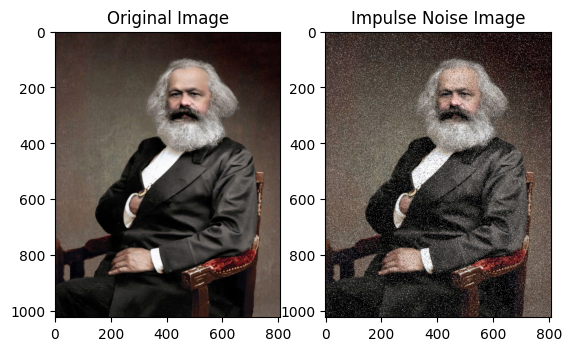

In [ ]:
input_img = cv.imread(imgKarlMax_path)
if input_img is not None:
    # Add impulse noise to the image
    noisy_image = add_impulse_noise(input_img, prob=0.1)

    # Save the resulting noisy image
    cv.imwrite('output_impulse_noise.jpg', noisy_image)

    # Display the original and noisy images using matplotlib
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(input_img, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
    plt.title('Impulse Noise Image')
    plt.show()
else:
    print("Unable to read the image from the provided path.")

**Gaussian noise**

In [ ]:
def add_gaussian_noise(image, mean, sigma):
    """
    Adds Gaussian noise to an image.

    Args:
    - image: Input image (numpy array).
    - mean: Mean of the Gaussian distribution (default is 0).
    - sigma: Standard deviation of the Gaussian distribution (controls noise intensity).

    Returns:
    - noisy_img: Image with added Gaussian noise.
    """
    # Generate Gaussian noise
    gaussian_noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)

    # Add the Gaussian noise to the image
    noisy_img = image.astype(np.float32) + gaussian_noise

    # Clip pixel values to be in the valid range [0, 255]
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    return noisy_img

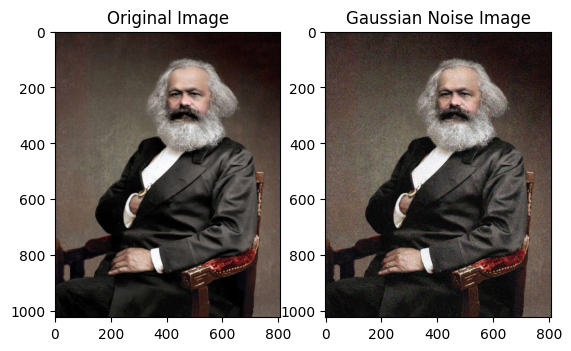

In [ ]:
input_img = cv.imread(imgKarlMax_path)
if input_img is not None:
    # Add impulse noise to the image
    noisy_image = add_gaussian_noise(input_img,0,25)

    # Save the resulting noisy image
    cv.imwrite('output_gaussian_noise.jpg', noisy_image)

    # Display the original and noisy images using matplotlib
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(input_img, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
    plt.title('Gaussian Noise Image')
    plt.show()
else:
    print("Unable to read the image from the provided path.")

**Speckle noise**

In [ ]:


def add_speckle_noise(image, sigma):
    """
    Adds speckle noise to an image.

    Args:
    - image: Input image (numpy array).
    - sigma: Standard deviation of the speckle noise (controls noise intensity).

    Returns:
    - noisy_img: Image with added speckle noise.
    """
    # Convert the image to float32 for accurate calculations
    image = image.astype(np.float32) / 255.0

    # Generate speckle noise (multiplicative noise)
    noise = np.random.randn(*image.shape) * sigma

    # Add the speckle noise to the image
    noisy_img = image + image * noise

    # Clip pixel values to the range [0, 1] and convert back to uint8
    noisy_img = np.clip(noisy_img, 0, 1)
    noisy_img = (noisy_img * 255).astype(np.uint8)

    return noisy_img




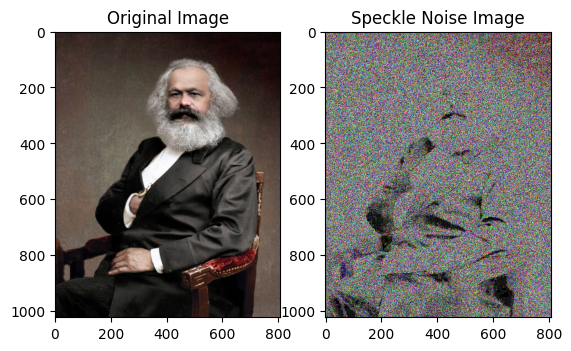

In [ ]:
input_img = cv.imread(imgKarlMax_path)
if input_img is not None:
    # Add impulse noise to the image
    noisy_image = add_speckle_noise(input_img,50)

    # Save the resulting noisy image
    cv.imwrite('output_speckle_noise.jpg', noisy_image)

    # Display the original and noisy images using matplotlib
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(input_img, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
    plt.title('Speckle Noise Image')
    plt.show()
else:
    print("Unable to read the image from the provided path.")

**Uniform Noise**

In [ ]:
def add_uniform_noise(img, noise_range):
    """
    Thêm nhiễu uniform vào ảnh đầu vào.

    Parameters:
        img (numpy.ndarray): Ảnh gốc (dạng mảng NumPy).
        noise_range (tuple): Khoảng giá trị nhiễu (min, max), thường nằm trong khoảng [-1, 1] nếu ảnh được chuẩn hóa.

    Returns:
        numpy.ndarray: Ảnh sau khi thêm nhiễu.
    """
    # Kiểm tra nếu ảnh có giá trị pixel từ 0 đến 255 thì chuẩn hóa về [0, 1]
    if img.dtype == np.uint8:
        img = img / 255.0

    # Tạo nhiễu uniform cùng kích thước với ảnh
    noise = np.random.uniform(low=noise_range[0], high=noise_range[1], size=img.shape)

    # Thêm nhiễu vào ảnh
    noisy_img = img + noise

    # Đảm bảo giá trị pixel nằm trong khoảng [0, 1]
    noisy_img = np.clip(noisy_img, 0, 1)

    # Chuyển ảnh về dạng uint8 nếu cần
    noisy_img = (noisy_img * 255).astype(np.uint8)

    return noisy_img


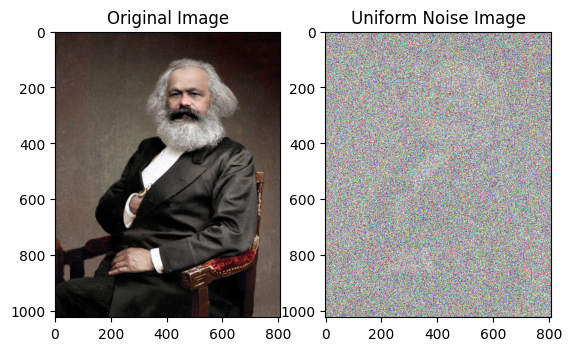

In [ ]:
input_img = cv.imread(imgKarlMax_path)
if input_img is not None:
    # Add impulse noise to the image
    noisy_image = add_uniform_noise(input_img,(-5, 10))

    # Save the resulting noisy image
    cv.imwrite('output_uniform_noise.jpg', noisy_image)

    # Display the original and noisy images using matplotlib
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(input_img, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
    plt.title('Uniform Noise Image')
    plt.show()
else:
    print("Unable to read the image from the provided path.")

# Filter

**Harmonic mean filter**

In [ ]:
def harmonic_mean_filter(noisy_image, kernel_size):
    """
    Apply Harmonic Mean Filter to denoise an image channel-wise.

    Parameters:
    noisy_image (numpy array): Input noisy image (color).
    kernel_size (int): Size of the filter kernel. Default is 3.

    Returns:
    numpy array: Denoised color image.
    """
    # Initialize the output image with the same shape as the input
    denoised_image = np.zeros_like(noisy_image, dtype=np.float32)

    # Process each color channel separately
    for c in range(3):  # Loop over B, G, R channels
        # Padding to handle borders for each channel
        pad_size = kernel_size // 2
        padded_channel = cv.copyMakeBorder(noisy_image[:, :, c], pad_size, pad_size, pad_size, pad_size, cv.BORDER_REFLECT)

        # Traverse each pixel in the channel
        for i in range(pad_size, padded_channel.shape[0] - pad_size):
            for j in range(pad_size, padded_channel.shape[1] - pad_size):
                # Extract the local neighborhood (kernel window) for the current channel
                local_region = padded_channel[i - pad_size:i + pad_size + 1, j - pad_size:j + pad_size + 1]

                # Calculate harmonic mean in the kernel region, avoiding zero values to prevent division errors
                local_region = local_region.astype(np.float32)
                harmonic_mean = kernel_size * kernel_size / np.sum(1.0 / (local_region + 1e-10))

                # Assign the harmonic mean to the output image's channel
                denoised_image[i - pad_size, j - pad_size, c] = harmonic_mean

    # Convert the image back to 8-bit format
    denoised_image = np.clip(denoised_image, 0, 255).astype(np.uint8)

    return denoised_image




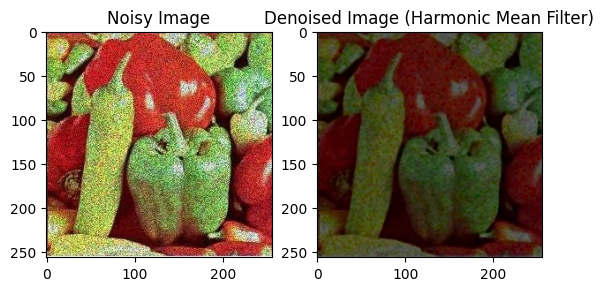

In [ ]:
# Load the noisy color image
noisy_image = cv.imread(imgNoiseFruit_path)

# Apply Harmonic Mean Filter on the color image
denoised_image = harmonic_mean_filter(noisy_image, kernel_size=2)

# Display the original noisy and denoised images
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
plt.title('Noisy Image')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(denoised_image, cv.COLOR_BGR2RGB))
plt.title('Denoised Image (Harmonic Mean Filter)')
plt.show()

**Geometric mean filter**

In [ ]:
def geometric_mean_filter(noisy_image, kernel_size):
    """
    Apply Geometric Mean Filter to denoise an image channel-wise.

    Parameters:
    noisy_image (numpy array): Input noisy image (color).
    kernel_size (int): Size of the filter kernel. Default is 3.

    Returns:
    numpy array: Denoised color image.
    """
    # Initialize the output image with the same shape as the input
    denoised_image = np.zeros_like(noisy_image, dtype=np.float32)

    # Process each color channel separately
    for c in range(3):  # Loop over B, G, R channels
        # Padding to handle borders for each channel
        pad_size = kernel_size // 2
        padded_channel = cv.copyMakeBorder(noisy_image[:, :, c], pad_size, pad_size, pad_size, pad_size, cv.BORDER_REFLECT)

        # Traverse each pixel in the channel
        for i in range(pad_size, padded_channel.shape[0] - pad_size):
            for j in range(pad_size, padded_channel.shape[1] - pad_size):
                # Extract the local neighborhood (kernel window) for the current channel
                local_region = padded_channel[i - pad_size:i + pad_size + 1, j - pad_size:j + pad_size + 1]

                # Calculate geometric mean, avoiding zero values with a small epsilon
                local_region = local_region.astype(np.float32) + 1e-10
                geometric_mean = np.exp(np.sum(np.log(local_region)) / (kernel_size * kernel_size))

                # Assign the geometric mean to the output image's channel
                denoised_image[i - pad_size, j - pad_size, c] = geometric_mean

    # Convert the image back to 8-bit format
    denoised_image = np.clip(denoised_image, 0, 255).astype(np.uint8)

    return denoised_image




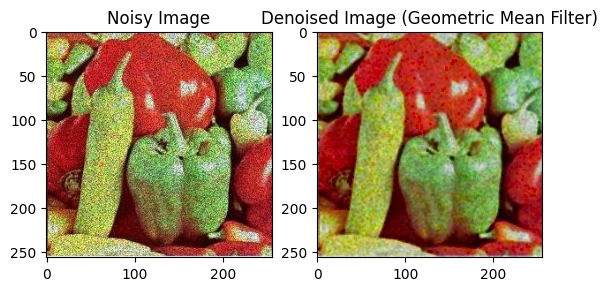

In [ ]:
# Load the noisy color image
noisy_image = cv.imread(imgNoiseFruit_path)

# Apply Geometric Mean Filter on the color image
denoised_image = geometric_mean_filter(noisy_image, kernel_size=3)

# Display the original noisy and denoised images
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
plt.title('Noisy Image')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(denoised_image, cv.COLOR_BGR2RGB))
plt.title('Denoised Image (Geometric Mean Filter)')
plt.show()

**Convolution filter**

In [ ]:
def apply_convolution_filter(image, kernel):
    """
    Apply a convolution filter to an image.

    Parameters:
    image (numpy array): Input color image.
    kernel (numpy array): Convolution kernel (filter) to apply.

    Returns:
    numpy array: Filtered color image.
    """
    # Apply the convolution filter to each color channel
    filtered_image = np.zeros_like(image)
    for c in range(3):  # Loop over B, G, R channels
        filtered_image[:, :, c] = cv.filter2D(image[:, :, c], -1, kernel)
    return filtered_image



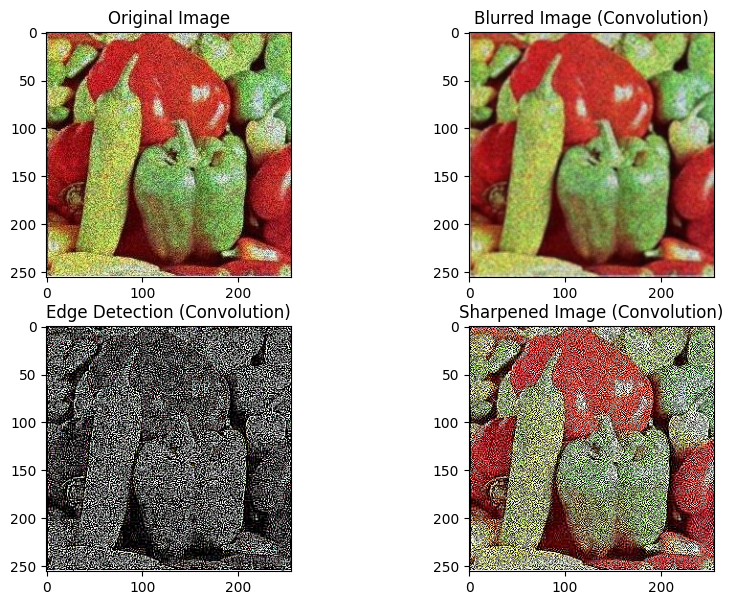

In [ ]:
# Load the input noise image
noisy_image = cv.imread(imgNoiseFruit_path)

# Define different kernels for various effects
# Blur kernel (averaging filter)
blur_kernel = np.ones((3, 3), np.float32) / 9

# Edge detection kernel (Sobel)
edge_kernel = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]], np.float32)

# Sharpen kernel
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], np.float32)

# Apply each filter
blurred_image = apply_convolution_filter(noisy_image, blur_kernel)
edge_image = apply_convolution_filter(noisy_image, edge_kernel)
sharpened_image = apply_convolution_filter(noisy_image, sharpen_kernel)

# Display the original and filtered images
plt.figure(figsize=(10, 7))
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(noisy_image, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(blurred_image, cv.COLOR_BGR2RGB))
plt.title('Blurred Image (Convolution)')
plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(edge_image, cv.COLOR_BGR2RGB))
plt.title('Edge Detection (Convolution)')
plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(sharpened_image, cv.COLOR_BGR2RGB))
plt.title('Sharpened Image (Convolution)')
plt.show()


# Denosing method

**Using function fastNlMeansDenoisingColored() of OpencV**


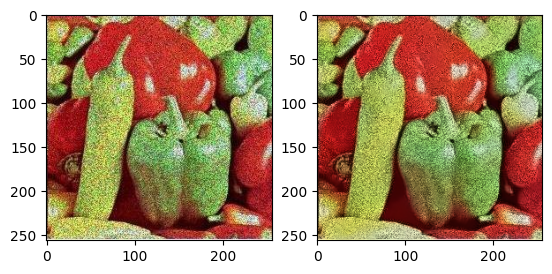

In [ ]:
img = cv.imread(imgNoiseFruit_path)
dst = cv.fastNlMeansDenoisingColored(img,None,10,10,7,21)
plt.subplot(121),plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.subplot(122),plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))
plt.show()

# BTVN

## Lý thuyết về  Noise

1. **Câu hỏi**: Uniform noise là gì? Khác biệt giữa uniform noise và Gaussian noise là gì?

2. **Câu hỏi**: Nêu một số ứng dụng thực tế của việc thêm noise vào dữ liệu hoặc ảnh trong lĩnh vực **Machine Learning** và **Computer Vision**.

---

**Phần 1.1: Thực hành trên Dữ liệu Số**

3. **Bài tập**: Sử dụng hàm gây nhiễu dữ liệu vừa được hướng dẫn ở trên  và thực hiện với ví dụ bên dưới

   **Ví dụ đầu vào**:
   ```python
   data = np.array([10, 20, 30, 40, 50])
   noisy_data = add_uniform_noise(data, noise_range=(-2, 2))
   print("Dữ liệu sau khi thêm nhiễu:", noisy_data)
   ```

   **Yêu cầu**:
   - Thực hiện chuẩn hóa mảng `data` về khoảng `[0, 1]` trước khi thêm nhiễu.
   - Đảm bảo giá trị của mảng sau khi thêm nhiễu vẫn nằm trong khoảng `[0, 1]`.

4. **Câu hỏi**: Thử nghiệm với các khoảng giá trị nhiễu khác nhau như `(-0.5, 0.5)` và `(-5, 10)`. Ghi lại quan sát của bạn về sự thay đổi của dữ liệu.

---

**Phần 1.1: Thực hành trên Ảnh**


5. **Bài tập mở rộng**:
    - Sử dụng ảnh bên ngoài và chạy với các giá trị tham số khác nhau của các hàm gây nhiễu vừa được hướng dẫn bên trên , sau đó vẽ histogram và rút ra nhận xét gì về ảnh ban đầu và ảnh nhiễu

6. **Câu hỏi**: Giải thích sự ảnh hưởng của nhiễu lên ảnh khi bạn thay đổi `noise_parameter`. Khi nào thì ảnh bị nhiễu quá mức đến mức không thể nhận dạng được? (bonus)

---



## Lý thuyết về  Noise

1. **Câu hỏi**: Uniform noise là gì? Khác biệt giữa uniform noise và Gaussian noise là gì?

2. **Câu hỏi**: Nêu một số ứng dụng thực tế của việc thêm noise vào dữ liệu hoặc ảnh trong lĩnh vực **Machine Learning** và **Computer Vision**.

---

## Lý thuyết về Noise

### 1. Uniform Noise và Gaussian Noise

**Uniform Noise:**

* **Định nghĩa:** Là loại nhiễu mà các giá trị của nó phân bố đều trong một khoảng xác định. Nói cách khác, mọi giá trị trong khoảng đó đều có xác suất xuất hiện như nhau.
* **Đặc trưng:**
    * Hình dạng đồ thị phân phối xác suất là một hình chữ nhật.
    * Thường được sử dụng để mô hình hóa các loại nhiễu ngẫu nhiên đơn giản.

**Gaussian Noise:**

* **Định nghĩa:** Là loại nhiễu mà các giá trị của nó tuân theo phân phối chuẩn (Gaussian).
* **Đặc trưng:**
    * Hình dạng đồ thị phân phối xác suất là đường cong hình chuông.
    * Thường được sử dụng để mô hình hóa nhiều loại nhiễu trong tự nhiên, đặc biệt là nhiễu điện tử.
* **Khác biệt với Uniform Noise:**
    * **Phân bố giá trị:** Uniform noise phân bố đều trong một khoảng, còn Gaussian noise tập trung quanh một giá trị trung bình và giảm dần về hai phía.
    * **Ứng dụng:** Gaussian noise thường được sử dụng rộng rãi hơn trong các mô hình toán học và xử lý tín hiệu do tính chất tự nhiên của nó.

### 2. Ứng dụng của việc thêm Noise vào dữ liệu hoặc ảnh

Việc thêm noise vào dữ liệu hoặc ảnh, một kỹ thuật gọi là **data augmentation**, được sử dụng rộng rãi trong lĩnh vực Machine Learning và Computer Vision để cải thiện độ chính xác và khả năng tổng quát của các mô hình.

**Ứng dụng trong Machine Learning:**

* **Tăng độ đa dạng của dữ liệu:**
    * Khi tập dữ liệu nhỏ, việc thêm noise giúp tạo ra nhiều phiên bản khác nhau của cùng một dữ liệu, giúp mô hình học được nhiều đặc trưng hơn và tránh overfitting.
* **Cải thiện khả năng tổng quát:**
    * Mô hình được huấn luyện trên dữ liệu có noise sẽ trở nên ổn định hơn với các biến đổi nhỏ trong dữ liệu đầu vào, giúp mô hình hoạt động tốt hơn trên dữ liệu chưa từng thấy.
* **Regularization:**
    * Việc thêm noise có thể coi như một hình thức regularization, giúp giảm overfitting bằng cách làm cho mô hình ít nhạy cảm hơn với các biến động nhỏ trong dữ liệu.

**Ứng dụng trong Computer Vision:**

* **Tăng cường độ bền của mô hình:**
    * Mô hình được huấn luyện trên ảnh có noise sẽ có khả năng nhận diện đối tượng tốt hơn trong điều kiện ánh sáng yếu, bị mờ hoặc nhiễu.
* **Tạo dữ liệu tổng hợp:**
    * Bằng cách thêm noise vào các ảnh gốc, chúng ta có thể tạo ra một lượng lớn dữ liệu tổng hợp để huấn luyện mô hình, đặc biệt khi tập dữ liệu thực tế có hạn.
* **Simulate real-world conditions:**
    * Việc thêm noise giúp mô phỏng các điều kiện thực tế khi thu thập dữ liệu, giúp mô hình hoạt động tốt hơn trong các ứng dụng thực tế.

**Ví dụ:**

Các ngành công nghiệp như hình ảnh y tế, nơi chẩn đoán phụ thuộc vào việc giảm nhiễu, có nhiều ứng dụng thực tế cho nhiễu hình ảnh. Giảm nhiễu trong cảm biến từ xa cung cấp cách diễn giải phù hợp về dữ liệu môi trường từ vệ tinh. Các vật thể trên trời xa được các nhà thiên văn học chụp lại, được hỗ trợ bởi việc giảm nhiễu. Giám sát trong các hệ thống an ninh giúp tăng thị lực, mà việc giảm nhiễu là điều cần thiết.

Để đạt được kết quả mong muốn trong nghệ thuật và nhiếp ảnh, có thể sử dụng giảm nhiễu một cách có chủ đích. Để phân tích chính xác, thị giác máy tính và máy học đòi hỏi các thuật toán mạnh mẽ cho các vấn đề về nhiễu. Các nhà khoa học pháp y phụ thuộc vào việc giảm nhiễu để giải thích đúng các phát hiện, ngay cả khi kính hiển vi cung cấp thông tin chi tiết về mẫu chính xác hơn. Thị giác ô tô, kiểm soát chất lượng công nghiệp và phát hiện lỗi chính xác về cơ bản cần giảm nhiễu.



## Câu 3-4

In [ ]:
def add_uniform_noise_to_data(data, noise_range):
    # Chuẩn hóa dữ liệu về khoảng [0, 1]
    data_min = np.min(data)
    data_max = np.max(data)
    normalized_data = (data - data_min) / (data_max - data_min)

    # Tạo nhiễu uniform
    noise = np.random.uniform(low=noise_range[0], high=noise_range[1], size=data.shape)

    # Thêm nhiễu vào dữ liệu
    noisy_data = normalized_data + noise

    # Giới hạn giá trị trong khoảng [0, 1]
    noisy_data = np.clip(noisy_data, 0, 1)

    return normalized_data, noisy_data

# Dữ liệu vào
data = np.array([10, 20, 30, 40, 50])

# khoảng nhiễu
noise_ranges = [(-2, 2), (-0.5, 0.5), (-5, 10)]

print("Dữ liệu ban đầu:", data)

for noise_range in noise_ranges:
    normalized_data, noisy_data = add_uniform_noise_to_data(data, noise_range=noise_range)
    print(f"\nKhoảng nhiễu {noise_range}:")
    print("Dữ liệu sau khi chuẩn hóa:", normalized_data)
    print("Dữ liệu sau khi thêm nhiễu:", noisy_data)


Dữ liệu ban đầu: [10 20 30 40 50]

Khoảng nhiễu (-2, 2):
Dữ liệu sau khi chuẩn hóa: [0.   0.25 0.5  0.75 1.  ]
Dữ liệu sau khi thêm nhiễu: [0.         0.         0.04787926 1.         1.        ]

Khoảng nhiễu (-0.5, 0.5):
Dữ liệu sau khi chuẩn hóa: [0.   0.25 0.5  0.75 1.  ]
Dữ liệu sau khi thêm nhiễu: [0.23995233 0.25771983 0.41238294 1.         1.        ]

Khoảng nhiễu (-5, 10):
Dữ liệu sau khi chuẩn hóa: [0.   0.25 0.5  0.75 1.  ]
Dữ liệu sau khi thêm nhiễu: [1.         1.         1.         0.13786968 1.        ]


### Nhận xét:
- Khoảng nhiễu (-2, 2): Thay đổi mạnh, nhiều giá trị bị giới hạn ở biên [0, 1]
[0,1].
- Khoảng nhiễu (-0.5, 0.5): Thay đổi nhẹ, dữ liệu vẫn giữ được trật tự, lý tưởng cho mô phỏng nhiễu thực tế.
- Khoảng nhiễu (-5, 10): Thay đổi lớn, nhiều giá trị bị đẩy về 0 hoặc 1

## Câu 5

Downloading...
From: https://drive.google.com/uc?id=1Gt3EaVta3Ea6NQfsaAaI7QYFaf1c9n1Z
To: /content/Car.jpg
100%|██████████| 260k/260k [00:00<00:00, 69.8MB/s]


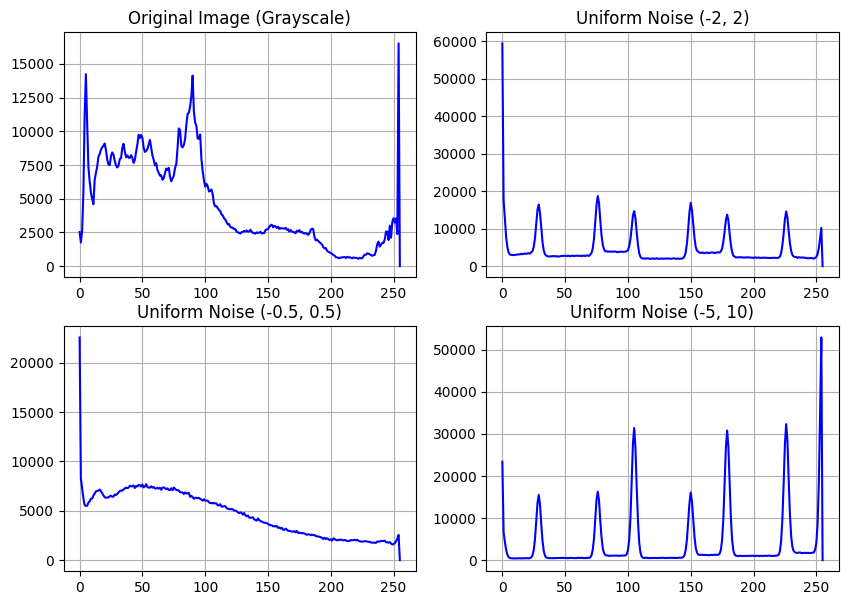

In [ ]:
gdown.download('https://drive.google.com/uc?id=1Gt3EaVta3Ea6NQfsaAaI7QYFaf1c9n1Z', 'Car.jpg', quiet=False)

fil_path = '/content'
imgCar = 'Car.jpg'
imgCar_path = os.path.join(fil_path, imgCar)

# Hàm vẽ histogram
def plot_gray_histogram(image_path, title):
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    hist = cv.calcHist([image], [0], None, [256], [0, 255])
    plt.plot(hist, color='blue')
    plt.title(title)
    plt.grid()

input_img1 = cv.imread(imgCar_path)
if input_img1 is not None:
    # Add uniform noise to the image
    noisy_image1_1 = add_uniform_noise(input_img1, (-2, 2))
    noisy_image1_2 = add_uniform_noise(input_img1, (-0.5, 0.5))
    noisy_image1_3 = add_uniform_noise(input_img1, (-5, 10))

    # Save the resulting noisy images
    cv.imwrite('output_uniform_noise1_1.jpg', noisy_image1_1)
    cv.imwrite('output_uniform_noise1_2.jpg', noisy_image1_2)
    cv.imwrite('output_uniform_noise1_3.jpg', noisy_image1_3)

    # Plot histograms in a 2x2 grid
    plt.figure(figsize=(10, 7))

    plt.subplot(221)
    plot_gray_histogram(imgCar_path, "Original Image (Grayscale)")

    plt.subplot(222)
    plot_gray_histogram('output_uniform_noise1_1.jpg', "Uniform Noise (-2, 2)")

    plt.subplot(223)
    plot_gray_histogram('output_uniform_noise1_2.jpg', "Uniform Noise (-0.5, 0.5)")

    plt.subplot(224)
    plot_gray_histogram('output_uniform_noise1_3.jpg', "Uniform Noise (-5, 10)")

    plt.show()

else:
    print("Unable to read the image from the provided path.")

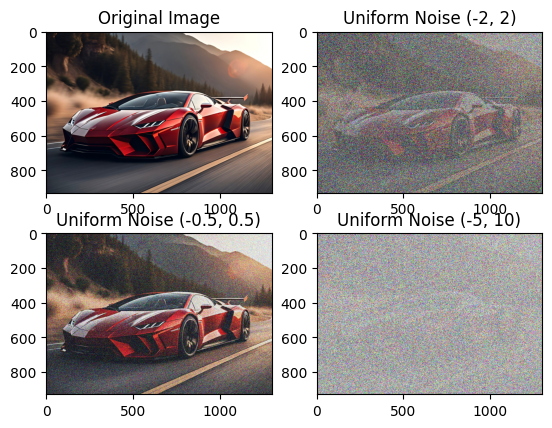

In [ ]:
plt.subplot(221)
plt.imshow(cv.cvtColor(input_img1, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.subplot(222)
plt.imshow(cv.cvtColor(noisy_image1_1, cv.COLOR_BGR2RGB))
plt.title('Uniform Noise (-2, 2)')
plt.subplot(223)
plt.imshow(cv.cvtColor(noisy_image1_2, cv.COLOR_BGR2RGB))
plt.title('Uniform Noise (-0.5, 0.5)')
plt.subplot(224)
plt.imshow(cv.cvtColor(noisy_image1_3, cv.COLOR_BGR2RGB))
plt.title('Uniform Noise (-5, 10)')
plt.show()

### Nhận xét:
1. Ảnh ban đầu (Original Image):
- Biểu đồ hiển thị phân phối pixel của ảnh gốc, tập trung vào các giá trị sáng (cao) và tối (thấp). Đây là histogram bình thường và phản ánh đúng độ sáng của ảnh.
2. Ảnh nhiễu với các mức nhiễu khác nhau:
- Nhiễu (-2, 2):
  - Pixel bị đẩy mạnh về hai biên giá trị (0 và 255), khiến phần lớn thông tin bị mất.
  - Ảnh trở nên cực kỳ nhiễu, khó nhận dạng và không giữ được đặc điểm của ảnh gốc.
- Nhiễu (-0.5, 0.5):
  - Nhiễu nhỏ (-0.5, 0.5) chỉ tạo ra thay đổi nhỏ trong giá trị pixel nên histogram vẫn khá giống với ảnh gốc.
  - Ảnh vẫn dễ nhận dạng, chỉ bị mờ nhẹ.
- Nhiễu (-5, 10):
  - Pixel bị dịch chuyển mạnh hơn, khiến phần lớn giá trị bị gom về 0 hoặc 255, tương tự như trường hợp (-2, 2) nhưng với mức độ nghiêm trọng hơn.
  - Ảnh gần như bị phá hủy hoàn toàn và không còn giữ được thông tin ban đầu.
  Histogram của ảnh gốc (Grayscale):


## Câu 6:
- Mức nhiễu nhỏ (−0.5,0.5) giữ thông tin gốc và nhận dạng được
- Mức nhiễu lớn ((−2,2), (−5,10)) có thể phá hủy cấu trúc và làm ảnh không thể nhận dạng
Ảnh bị nhiễu quá mức khi `noise_parameter` quá lớn so với dải giá trị pixel, dẫn đến pixel bị gom về biên làm mất thông tin chi tiết của ảnh.



# Áp dụng bộ lọc tích chập và lọc ảnh

## Phần 1: Áp dụng các bộ lọc tích chập cơ bản
1. **Mục tiêu**: Áp dụng các bộ lọc làm mờ, phát hiện cạnh, và làm sắc nét để hiểu cách chúng thay đổi đặc điểm của ảnh.
2. **Yêu cầu**:
   - Tải một ảnh màu và chuyển nó thành ảnh grayscale (ảnh xám).
   - So sánh các ảnh đầu ra bằng cách hiển thị ảnh gốc và ảnh sau khi áp dụng từng bộ lọc.



## Phần 2: Bộ lọc Harmonic Mean và Geometric Mean

2. **Yêu cầu**:
   - Tạo một ảnh nhiễu Gaussian
   - Viết các hàm áp dụng bộ lọc Harmonic Mean và Geometric Mean.
   - Áp dụng các bộ lọc này với kích thước kernel khác nhau (3x3 và 5x5) sai đó so sánh kết quả và rút ra nhận xét.



## Bài tập mở rộng(bonus):
1. **Ứng dụng các bộ lọc trong thực tế**:
   - Áp dụng các bộ lọc tích chập trên một ảnh thực tế chứa văn bản và các chi tiết nhỏ để xem bộ lọc nào phù hợp nhất trong việc tăng cường hoặc giảm nhiễu mà vẫn giữ được các chi tiết quan trọng.
   

   
2. **So sánh bộ lọc**:
   - Đối với ảnh chứa nhiễu nặng, hãy thử so sánh hiệu quả của các bộ lọc khác nhau như Harmonic Mean, Geometric Mean, Convolutional filter
3. **Tìm hiểu về Hàm fastNlMeansDenoisingColored()**:
  - Nêu ý nghĩa các tham số của hàm
4. **Nêu ý kiến về sự khác biệt và giống nhau giữa 2 kỹ thuật denoise và filtering**?



## Phần 1: Áp dụng các bộ lọc tích chập cơ bản

In [ ]:
gdown.download('https://drive.google.com/uc?id=19irMCB7GsNm_a2bsv2kMI0NrpK2shx-m', 'Cat.jpg', quiet=False)

fil_path = '/content'
imgCat = 'Cat.jpg'
imgCat_path = os.path.join(fil_path, imgCat)

Downloading...
From: https://drive.google.com/uc?id=19irMCB7GsNm_a2bsv2kMI0NrpK2shx-m
To: /content/Cat.jpg
100%|██████████| 83.7k/83.7k [00:00<00:00, 10.8MB/s]


In [ ]:
def apply_convolution_filter_gray(image, kernel):
    """
    Áp dụng bộ lọc tích chập cho ảnh grayscale.

    Parameters:
    image (numpy array): Ảnh đầu vào (grayscale).
    kernel (numpy array): Ma trận kernel của bộ lọc.

    Returns:
    numpy array: Ảnh đã được lọc (grayscale).
    """
    # Kiểm tra xem ảnh đầu vào có phải là ảnh grayscale không
    if len(image.shape) != 2:
        raise ValueError("Ảnh đầu vào phải là ảnh grayscale (2 chiều).")

    # Áp dụng bộ lọc sử dụng cv.filter2D
    filtered_image = cv.filter2D(image, -1, kernel)

    return filtered_image

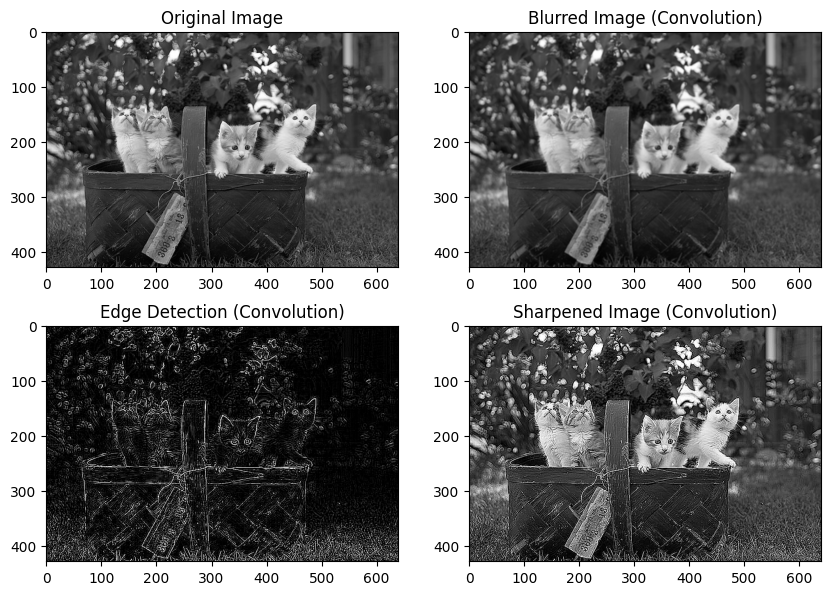

In [ ]:
img_cat = cv.imread(imgCat_path,cv.IMREAD_GRAYSCALE)

# Define different kernels for various effects
# Blur kernel (averaging filter)
blur_kernel = np.ones((3, 3), np.float32) / 9

# Edge detection kernel (Sobel)
edge_kernel = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]], np.float32)

# Sharpen kernel
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], np.float32)

#Áp dụng từng bộ lọc
blur_image = apply_convolution_filter_gray(img_cat, blur_kernel)
edged_image = apply_convolution_filter_gray(img_cat, edge_kernel)
sharpen_image = apply_convolution_filter_gray(img_cat, sharpen_kernel)
plt.figure(figsize=(10, 7))
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(img_cat, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(blur_image, cv.COLOR_BGR2RGB))
plt.title('Blurred Image (Convolution)')
plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(edged_image, cv.COLOR_BGR2RGB))
plt.title('Edge Detection (Convolution)')
plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(sharpen_image, cv.COLOR_BGR2RGB))
plt.title('Sharpened Image (Convolution)')
plt.show()


## Phần 2: Bộ lọc Harmonic Mean và Geometric Mean

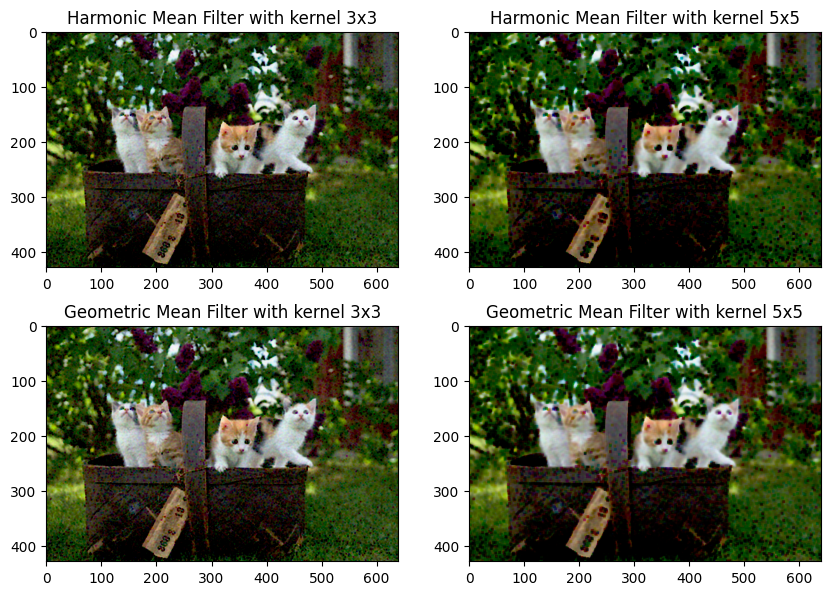

In [ ]:
img_cat_2 = cv.imread(imgCat_path)
#Tạo ảnh nhiễu Gauss
noisy_cat = add_gaussian_noise(img_cat_2,0,25)
cv.imwrite('output_cat_gaussian_noise.jpg', noisy_cat)

#Áp dụng bộ lọc Geometric và Harmonic
harmonic_3x3 = harmonic_mean_filter(noisy_cat, kernel_size=3)
harmonic_5x5 = harmonic_mean_filter(noisy_cat, kernel_size=5)
geometric_3x3 = geometric_mean_filter(noisy_cat, kernel_size=3)
geometric_5x5 = geometric_mean_filter(noisy_cat, kernel_size=5)

#Display
plt.figure(figsize=(10, 7))

plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(harmonic_3x3, cv.COLOR_BGR2RGB))
plt.title('Harmonic Mean Filter with kernel 3x3')
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(harmonic_5x5, cv.COLOR_BGR2RGB))
plt.title('Harmonic Mean Filter with kernel 5x5')
plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(geometric_3x3, cv.COLOR_BGR2RGB))
plt.title('Geometric Mean Filter with kernel 3x3')
plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(geometric_5x5, cv.COLOR_BGR2RGB))
plt.title('Geometric Mean Filter with kernel 5x5')
plt.show()


**Nhận xét:**
1. Harmonic Mean Filter (3x3):
giảm nhiễu tốt nhưng vẫn giữ được chi tiết, màu sắc hình vẫn tự nhiên.
Các chi tiết của lông mèo và giỏ vẫn tương đối rõ
2. Harmonic Mean Filter (5x5):
giảm nhiễu mạnh hơn 3x3, chi tiết ảnh đã bị mờ nhiều, màu sắc đậm hơn
3. Geometric Mean Filter (3x3):
giảm nhiễu nhẹ hơn harmonic, màu có vẻ sáng hơn so với harmonic
4. Geometric Mean Filter (5x5):
tương tự Harmonic Mean Filter (5x5):
độ mờ tương đối, vẫn giữ được nhiều chi tiết hơn so với Harmonic 5x5 và
màu sắc ít bị ảnh hưởng hơn

## Bài tập mở rộng(bonus):

### 1. Ứng dụng các bộ lọc trong thực tế:
Áp dụng các bộ lọc tích chập trên một ảnh thực tế chứa văn bản và các chi tiết nhỏ để xem bộ lọc nào phù hợp nhất trong việc tăng cường hoặc giảm nhiễu mà vẫn giữ được các chi tiết quan trọng.

In [ ]:
gdown.download('https://drive.google.com/uc?id=14gyTXy2uXyEfJtmex_VqGpfjcNPVGolH', 'Text.jpg', quiet=False)

fil_path = '/content'
imgText = 'Text.jpg'
imgText_path = os.path.join(fil_path, imgText)

Downloading...
From: https://drive.google.com/uc?id=14gyTXy2uXyEfJtmex_VqGpfjcNPVGolH
To: /content/Text.jpg
100%|██████████| 525k/525k [00:00<00:00, 89.3MB/s]


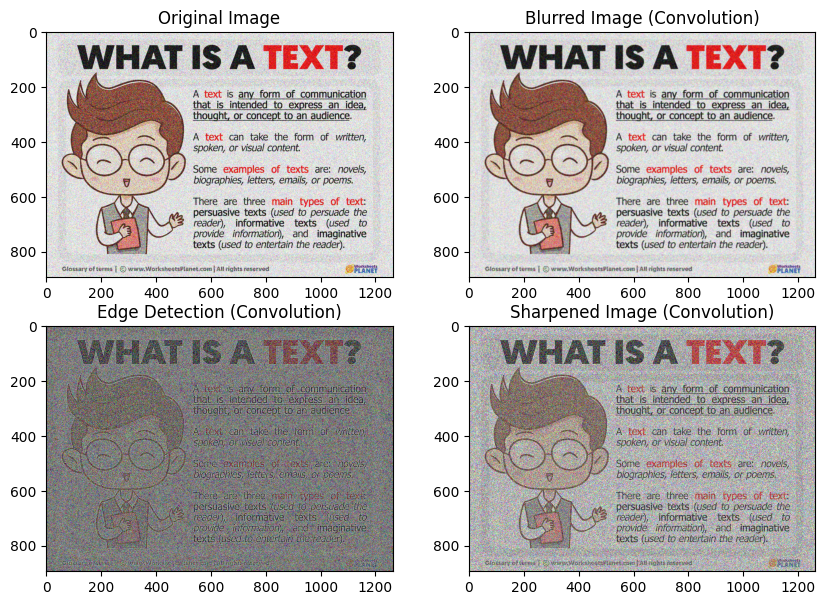

In [ ]:
# Tạo ảnh nhiễu
img_text = cv.imread(imgText_path)
noisy_text = add_uniform_noise(img_text,(-0.5, 0.5))
cv.imwrite('output_text_uniform_noise.jpg', noisy_text)

blurred_image_bonus = apply_convolution_filter(noisy_text, blur_kernel)
edge_image_bonus = apply_convolution_filter(noisy_text, edge_kernel)
sharpened_image_bonus = apply_convolution_filter(noisy_text, sharpen_kernel)

# Display the original and filtered images
plt.figure(figsize=(10, 7))
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(noisy_text, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(blurred_image_bonus, cv.COLOR_BGR2RGB))
plt.title('Blurred Image (Convolution)')
plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(edge_image_bonus, cv.COLOR_BGR2RGB))
plt.title('Edge Detection (Convolution)')
plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(sharpened_image_bonus, cv.COLOR_BGR2RGB))
plt.title('Sharpened Image (Convolution)')
plt.show()


1. Original Image:
Hình ảnh ban đầu bị nhiễu nhẹ vẫn giữ được chi tiết tốt
2. Blurred Image (Convolution):
Văn bản bị mờ nhẹ nhưng vẫn đọc được.
Giảm nhiễu tốt.
3. Edge Detection (Convolution):
Tăng cường các đường viền và cạnh, nhưng các vùng chi tiết như văn bản bị loại bỏ, chỉ còn lại khung cơ bản của chữ và hình.
4. Sharpened Image (Convolution):
Có thể đọc được các chi tiết nhưng vẫn mờ.

> Tóm lại: ở hình này sẽ chọn bộ lọc Blurred

### 2. So sánh bộ lọc:
Đối với ảnh chứa nhiễu nặng, hãy thử so sánh hiệu quả của các bộ lọc khác nhau như Harmonic Mean, Geometric Mean, Convolutional filter

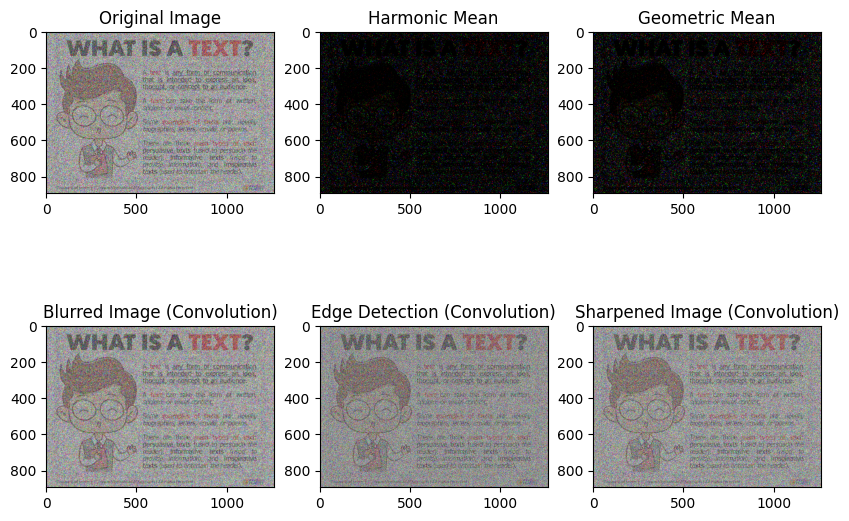

In [ ]:
noisy_text_2 = add_uniform_noise(img_text,(-2, 2))
cv.imwrite('output_text_uniform_noise_2.jpg', noisy_text_2)

#Áp dụng Harmonic Mean, Geometric Mean, Convolutional filter
harmonic_denoised = harmonic_mean_filter(noisy_text_2, kernel_size=3)
geometric_denoised = geometric_mean_filter(noisy_text_2, kernel_size=3)
blurred_image = apply_convolution_filter(noisy_text_2, blur_kernel)
edge_image = apply_convolution_filter(noisy_text_2, edge_kernel)
sharpened_image = apply_convolution_filter(noisy_text_2, sharpen_kernel)

# Hiển thị ảnh sau khi áp dụng các bộ lọc
plt.figure(figsize=(10,7))

plt.subplot(231)
plt.imshow(cv.cvtColor(noisy_text_2, cv.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(232)
plt.imshow(cv.cvtColor(harmonic_denoised, cv.COLOR_BGR2RGB))
plt.title("Harmonic Mean")

plt.subplot(233)
plt.imshow(cv.cvtColor(geometric_denoised, cv.COLOR_BGR2RGB))
plt.title("Geometric Mean")

plt.subplot(234)
plt.imshow(cv.cvtColor(blurred_image, cv.COLOR_BGR2RGB))
plt.title("Blurred Image (Convolution)")

plt.subplot(235)
plt.imshow(cv.cvtColor(edge_image, cv.COLOR_BGR2RGB))
plt.title("Edge Detection (Convolution)")

plt.subplot(236)
plt.imshow(cv.cvtColor(sharpened_image, cv.COLOR_BGR2RGB))
plt.title("Sharpened Image (Convolution)")

plt.show()


### 3. Tìm hiểu về Hàm fastNlMeansDenoisingColored():

```python
cv.fastNlMeansDenoisingColored(src[, dst[, h[, hColor[, templateWindowSize[, searchWindowSize]]]]]) ->dst
```

Hàm `fastNlMeansDenoisingColored()` trong OpenCV được sử dụng để khử nhiễu cho ảnh màu bằng thuật toán Non-Local Means. Các tham số của hàm này bao gồm:

1. **`src` (InputArray):**
   - Ảnh đầu vào (ảnh màu 3 kênh, định dạng 8-bit).
   - Đây là ảnh cần xử lý để khử nhiễu.

2. **`dst` (OutputArray):**
   - Ảnh đầu ra sau khi khử nhiễu, có cùng kích thước và định dạng với ảnh đầu vào.

3. **`h`:**
   - Tham số điều chỉnh cường độ bộ lọc cho thành phần độ sáng. Giá trị h lớn hơn loại bỏ hoàn toàn nhiễu nhưng cũng loại bỏ chi tiết hình ảnh, giá trị h nhỏ hơn giữ nguyên chi tiết nhưng cũng giữ nguyên một số nhiễu

4. **`hColor`:**
   - 	Giống như `h` nhưng đối với các thành phần màu. Đối với hầu hết các hình ảnh, giá trị bằng 10 sẽ đủ để loại bỏ nhiễu màu và không làm biến dạng màu

5. **`templateWindowSize`:**
   - Kích thước tính bằng pixel của bản vá mẫu được sử dụng để tính trọng số. Phải là số lẻ. Giá trị khuyến nghị là 7 pixel

6. **`searchWindowSize`:**
   - 	Kích thước tính bằng pixel của cửa sổ được sử dụng để tính toán trung bình có trọng số cho pixel đã cho. Phải là số lẻ. Ảnh hưởng đến hiệu suất theo tuyến tính: searchWindowsSize lớn hơn - thời gian khử nhiễu lớn hơn. Giá trị khuyến nghị 21 pixel


### 4. Nêu ý kiến về sự khác biệt và giống nhau giữa 2 kỹ thuật denoise và filtering?


#### **Denoising**

* **Mục tiêu:**
    * Loại bỏ nhiễu để cải thiện chất lượng hình ảnh, tăng độ rõ nét và chi tiết.
    * Tạo nền tảng tốt hơn cho các bước xử lý hình ảnh tiếp theo như phân đoạn, nhận dạng đối tượng.
* **Các phương pháp phổ biến:**
    * **Lọc trung bình (Mean filter):** Thay thế giá trị pixel bằng giá trị trung bình của các pixel lân cận.
    * **Lọc Gaussian:** Sử dụng trọng số Gaussian để tính giá trị trung bình, ưu tiên các pixel gần hơn.
    * **Lọc trung vị (Median filter):** Thay thế giá trị pixel bằng trung vị của các pixel lân cận, hiệu quả với nhiễu impulse.
    * **Non-local means:** So sánh các patch (vùng nhỏ) xung quanh pixel hiện tại với các patch khác trong ảnh để tìm các patch tương tự và tính giá trị trung bình có trọng số.
    * **Phương pháp dựa trên học sâu:** Sử dụng mạng thần kinh để học cách khử nhiễu từ một lượng lớn dữ liệu huấn luyện.

#### **Filtering**

* **Mục tiêu:**
    * Thay đổi đặc tính của hình ảnh theo ý muốn, như làm mờ, làm sắc nét, tăng cường cạnh, trích xuất các đặc trưng nhất định.
    * Chuẩn bị hình ảnh cho các ứng dụng khác nhau như xử lý ảnh y tế, thị giác máy tính.
* **Các loại bộ lọc:**
    * **Lọc thông thấp (Low-pass filter):** Làm mờ hình ảnh, loại bỏ nhiễu và chi tiết nhỏ.
    * **Lọc thông cao (High-pass filter):** Tăng cường cạnh và chi tiết, thường dùng để phát hiện cạnh.
    * **Bộ lọc Bilateral:** Kết hợp giữa lọc không gian và lọc dựa trên cường độ, bảo toàn cạnh và giảm nhiễu hiệu quả.
    * **Bộ lọc Sobel, Laplacian:** Phát hiện cạnh.
    * **Bộ lọc Gabor:** Phân tích các đặc trưng về tần số và hướng của hình ảnh.

#### **Sự khác biệt rõ ràng hơn**

| Đặc điểm | Denoising | Filtering |
|---|---|---|
| **Mục tiêu chính** | Loại bỏ nhiễu | Thay đổi đặc tính hình ảnh |
| **Kết quả mong muốn** | Hình ảnh sạch, rõ nét | Hình ảnh phù hợp với mục đích xử lý |
| **Các phương pháp** | Chủ yếu tập trung vào giảm nhiễu | Đa dạng các loại bộ lọc, tùy thuộc vào mục tiêu |
| **Ứng dụng** | Chuẩn bị hình ảnh cho các bước xử lý tiếp theo, cải thiện chất lượng hình ảnh | Xử lý ảnh y tế, thị giác máy tính, tăng cường hình ảnh, ... |

#### **Tóm lại**

* **Denoising** thường được xem là một dạng của **filtering**, nhưng với mục tiêu cụ thể hơn là loại bỏ nhiễu.
* Việc lựa chọn phương pháp denoising hoặc filtering phụ thuộc vào loại nhiễu, mức độ nhiễu và mục tiêu xử lý hình ảnh.
* Trong nhiều trường hợp, denoising và filtering được kết hợp để đạt được kết quả tốt nhất.
